Dataset :

    user_id  movie_id  rating
0         0         0       5
1         0         1       4
2         0         2       3
3         1         0       4
4         1         1       5
5         1         3       2
6         2         0       2
7         2         2       5
8         2         3       4
9         3         1       5
10        3         2       4
11        3         3       3


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ User_Input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Movie_Input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ User_Embedding      │ (None, 1, 50)     │        200 │ User_Input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Movie_Embedding     │ (None, 1, 50)     │        200 │ Movie_Input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50)        │          0 │ User_Embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 50)        │          0 │ Movie_Embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 100)       │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     12,928 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,697 (92.57 KB)

 Trainable params: 23,697 (92.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - loss: 15.4976 - mae: 3.7695 - val_loss: 16.0426 - val_mae: 3.9235
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 14.9404 - mae: 3.6955 - val_loss: 15.5191 - val_mae: 3.8566
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 14.3985 - mae: 3.6184 - val_loss: 14.9050 - val_mae: 3.7762
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 13.7122 - mae: 3.5226 - val_loss: 14.1654 - val_mae: 3.6775
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 12.8712 - mae: 3.4029 - val_loss: 13.2868 - val_mae: 3.5572
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 11.8516 - mae: 3.2467 - val_loss: 12.1937 - val_mae: 3.4019
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 10.5892 - mae: 3.0432 - val_loss: 10.8475 - val_mae: 3.2012
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 8.8766 - mae: 2.7718 - val_loss: 9.2465 - val_mae: 2.9450
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 7.1967 

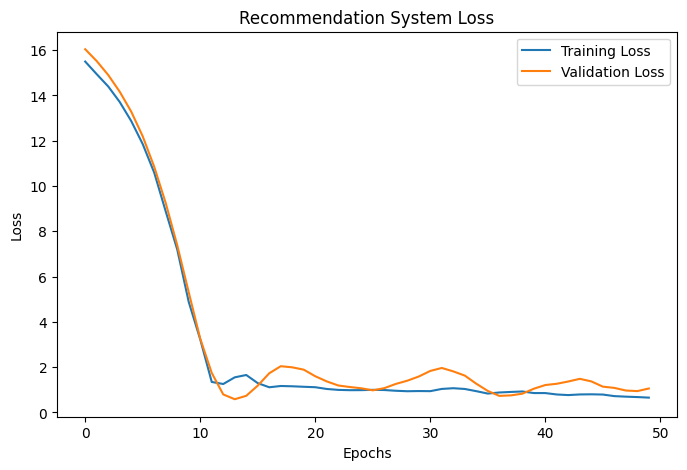

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step

Predicted Rating : 3.9461894


In [1]:
# Experiment No. 3
# Title: Neural Recommendation System using Keras

# Aim:
# To implement a Neural Recommendation System using Embedding Layers
# in TensorFlow and Keras.

# Import Required Libraries
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Concatenate

# Create Sample Recommendation Dataset
ratings_dict = {

    'user_id': [0,0,0,1,1,1,2,2,2,3,3,3],

    'movie_id': [0,1,2,0,1,3,0,2,3,1,2,3],

    'rating': [5,4,3,4,5,2,2,5,4,5,4,3]
}

ratings_df = pd.DataFrame(ratings_dict)

print("Dataset :\n")
print(ratings_df)

# Parameters
num_users = ratings_df['user_id'].nunique()
num_movies = ratings_df['movie_id'].nunique()

embedding_size = 50

# Input Layers
user_input = Input(
    shape=(1,),
    name='User_Input'
)

movie_input = Input(
    shape=(1,),
    name='Movie_Input'
)

# User Embedding
user_embedding = Embedding(
    input_dim=num_users,
    output_dim=embedding_size,
    name='User_Embedding'
)(user_input)

# Movie Embedding
movie_embedding = Embedding(
    input_dim=num_movies,
    output_dim=embedding_size,
    name='Movie_Embedding'
)(movie_input)

# Flatten Embeddings
user_vector = Flatten()(user_embedding)
movie_vector = Flatten()(movie_embedding)

# Concatenate Embeddings
concatenated = Concatenate()(
    [user_vector, movie_vector]
)

# Dense Layers
x = Dense(
    128,
    activation='relu'
)(concatenated)

x = Dense(
    64,
    activation='relu'
)(x)

x = Dense(
    32,
    activation='relu'
)(x)

# Output Layer
output = Dense(
    1,
    activation='linear'
)(x)

# Build Model
model = Model(
    inputs=[user_input, movie_input],
    outputs=output
)

# Model Summary
model.summary()

# Compile Model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Prepare Dataset
users = ratings_df['user_id'].values
movies = ratings_df['movie_id'].values
ratings = ratings_df['rating'].values

# Train Model
history = model.fit(
    [users, movies],
    ratings,
    epochs=50,
    batch_size=4,
    validation_split=0.2
)

# Plot Training Loss
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Recommendation System Loss')
plt.legend()

plt.show()

# Predict Rating
predicted_rating = model.predict(
    [
        np.array([1]),
        np.array([2])
    ]
)

print("\nPredicted Rating :", predicted_rating[0][0])

# Conclusion
# Successfully implemented a Neural Recommendation System
# using Embedding Layers in TensorFlow and Keras.